# NLP Sentiment Analysis on Amazon Reviews
**Business Objective:** Extract sentiment from customer reviews on a product to classify them as Positive, Negative, or Neutral.

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

try:
    import openpyxl
except ImportError:
    print("openpyxl not installed, install if reading .xlsx files")

## 1: Data Loading & Inspection 
We begin by loading the Amazon reviews dataset. Our primary focus will be on the `rating` (1-5 stars) and the `body` (the actual text written by the customer).

In [47]:
df = pd.read_excel('Group Details.xlsx', engine='openpyxl')
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [48]:
df = pd.read_excel('Group Details.xlsx')
df

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."
...,...,...,...
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."


In [49]:
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [50]:
df.tail()

,title,rating,body
1435,Excellent mobile,5,Excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve..."
1437,Good value for money,5,Battery life is good but camera clarity could ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied....."
1439,Beast of the best.,5,The phone is a real beast the battery lasts ea...


### 1.1 Data Check
Before processing, we must ensure our data is clean and handle any missing values. Missing text cannot be vectorized.

In [51]:
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [52]:
df[['rating','body']].head()

,rating,body
0,1,Very disappointed with the overall performance...
1,3,Camera quality is low
2,4,"Got the mobile on the launch date,Battery must..."
3,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,1,"Not worth buying....faulty software, poor disp..."


## 2: Target Variable Creation 
Machine Learning models require clear labels. We convert the 1-5 star numerical ratings into three distinct sentiment classes:
* **Negative:** 1-2 stars
* **Neutral:** 3 stars
* **Positive:** 4-5 stars

In [53]:
def map_sentiment(rating):
    if rating <= 2:
        return 'Negative'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Positive'

In [54]:
df['Sentiment'] = df['rating'].apply(map_sentiment)

df['Sentiment'].value_counts()

Sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

## 3: Exploratory Data Analysis (EDA) 
We visualize the distribution of our target variable (Sentiment) to check for class imbalance. Knowing if we have significantly more positive reviews than negative ones is crucial for evaluating our model later.

C:\Users\HP\AppData\Local\Temp\ipykernel_16068\2028855057.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment',order=['Negative','Neutral','Positive'],


Text(0, 0.5, 'Count')

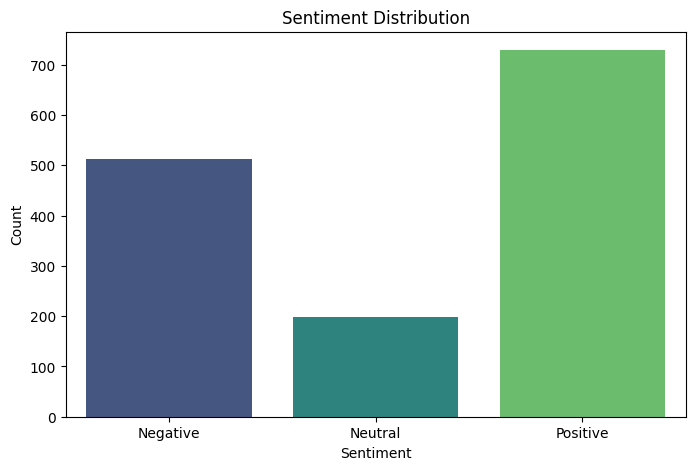

In [55]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment',order=['Negative','Neutral','Positive'],
              data=df,palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')


##  4: Text Preprocessing 
Raw text contains noise that algorithms cannot process efficiently. We apply the following cleaning steps using Regular Expressions (`re`) and Natural Language Toolkit (`nltk`):
1. **Lowercase:** Standardizing text (e.g., 'Good' and 'good' become identical).
2. **Punctuation Removal:** Stripping special characters and numbers.
3. **Stop Words Removal:** Filtering out common grammatical words (e.g., 'is', 'the', 'and') that carry little emotional weight.

In [56]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
def clean_text(text):
    text = str(text).lower() 
    text = re.sub(r'[^a-z\s]', '', text) 
    words = text.split() 
    cleaned_words = [word for word in words if word not in stop_words] 
    
    return ' '.join(cleaned_words)

In [58]:
df['cleaned_review'] = df['body'].apply(clean_text)
print(df[['body', 'cleaned_review']].head())

                                                body  \
0  Very disappointed with the overall performance...   
1                              Camera quality is low   
2  Got the mobile on the launch date,Battery must...   
3  1. It doesn't work with 5.0GHz WiFi frequency....   
4  Not worth buying....faulty software, poor disp...   

                                      cleaned_review  
0           disappointed overall performance samsung  
1                                 camera quality low  
2  got mobile launch datebattery must appreciated...  
3  doesnt work ghz wifi frequency ghz old school ...  
4  worth buyingfaulty software poor display quali...  


##  5: Feature Engineering (Text Vectorization) 
Machine Learning models only understand mathematics. We convert our cleaned text into a numerical matrix using **TF-IDF (Term Frequency-Inverse Document Frequency)**. 
* We limit the vocabulary to the top 2,500 most frequent words (`max_features=2500`) to optimize memory and processing speed.
* `X` represents our Feature Matrix.
* `y` represents our Target Labels.
*(Note for next milestone: Data will be split into training and testing sets to prevent data leakage prior to modeling).*

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [60]:
vecotorizer=TfidfVectorizer(max_features=5000)
x=vecotorizer.fit_transform(df['cleaned_review'])
y=df['Sentiment']

In [61]:
TfidfVectorizer(ngram_range=(1,2))

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [62]:
df

,title,rating,body,Sentiment,cleaned_review
0,Horrible product,1,Very disappointed with the overall performance...,Negative,disappointed overall performance samsung
1,Camera quality is not like 48 megapixel,3,Camera quality is low,Neutral,camera quality low
2,Overall,4,"Got the mobile on the launch date,Battery must...",Positive,got mobile launch datebattery must appreciated...
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....,Negative,doesnt work ghz wifi frequency ghz old school ...
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp...",Negative,worth buyingfaulty software poor display quali...
...,...,...,...,...,...
1435,Excellent mobile,5,Excellent mobile,Positive,excellent mobile
1436,Never expected from samsung,1,"All over mobile performance is very poor, neve...",Negative,mobile performance poor never buy one product ...
1437,Good value for money,5,Battery life is good but camera clarity could ...,Positive,battery life good camera clarity could little ...
1438,Unreal and whitish display,1,"It's a very bad product, highly dissatisfied.....",Negative,bad product highly dissatisfied specifically c...


In [63]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [64]:
from sklearn.naive_bayes import MultinomialNB

In [65]:
model=MultinomialNB()
model.fit(x_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [66]:
y_pred=model.predict(x_test)
y_pred

array(['Positive', 'Negative', 'Positive', 'Negative', 'Positive',
       'Positive', 'Negative', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Negative', 'Positive',
       'Negative', 'Positive', 'Negative', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Negative',
       'Positive', 'Positive', 'Positive', 'Negative', 'Positive',
       'Positive', 'Negative', 'Positive', 'Negative', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Positive', 'Negative', 'Negative',
       'Positive', 'Negative', 'Positive', 'Negative', 'Positive',
       'Negative', 'Positive', 'Positive', 'Negative', 'Negative',
       'Positive', 'Positive', 'Positive', 'Positive', 'Positive',
       'Positive', 'Positive', 'Negative', 'Positive', 'Positive',
       'Negative', 'Positive', 'Positive', 'Positive', 'Positi

In [67]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.6770833333333334

In [68]:
from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred)
cm

array([[ 63,   0,  48],
       [  2,   0,  42],
       [  1,   0, 132]])

In [69]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

    Negative       0.95      0.57      0.71       111
     Neutral       0.00      0.00      0.00        44
    Positive       0.59      0.99      0.74       133

    accuracy                           0.68       288
   macro avg       0.52      0.52      0.49       288
weighted avg       0.64      0.68      0.62       288



c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [70]:
df['Sentiment'].value_counts()

Sentiment
Positive    729
Negative    512
Neutral     199
Name: count, dtype: int64

In [71]:
from sklearn.linear_model import LogisticRegression
lr_model=LogisticRegression(max_iter=1000)
lr_model.fit(x_train,y_train)
y_pred_lr=lr_model.predict(x_test)

In [72]:
accuracy=accuracy_score(y_test,y_pred_lr)
accuracy

0.7673611111111112

In [73]:
cm=confusion_matrix(y_test,y_pred_lr)
cm

array([[ 93,   0,  18],
       [  8,   1,  35],
       [  6,   0, 127]])

In [74]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

    Negative       0.87      0.84      0.85       111
     Neutral       1.00      0.02      0.04        44
    Positive       0.71      0.95      0.81       133

    accuracy                           0.77       288
   macro avg       0.86      0.61      0.57       288
weighted avg       0.81      0.77      0.71       288



In [75]:
from sklearn.svm import LinearSVC
svm_model=LinearSVC()

In [76]:
svm_model.fit(x_train,y_train)
y_pred_svm=svm_model.predict(x_test)

In [77]:
accuracy=accuracy_score(y_test,y_pred_svm)
accuracy

0.78125

In [78]:
cm=confusion_matrix(y_test,y_pred_svm)
cm

array([[ 97,   3,  11],
       [  8,   9,  27],
       [ 11,   3, 119]])

In [79]:
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

    Negative       0.84      0.87      0.85       111
     Neutral       0.60      0.20      0.31        44
    Positive       0.76      0.89      0.82       133

    accuracy                           0.78       288
   macro avg       0.73      0.66      0.66       288
weighted avg       0.76      0.78      0.75       288



| Model               | Accuracy |
| ------------------- | -------- |
| Naive Bayes         | 0.67     |
| Logistic Regression | 0.76     |
| SVM (LinearSVC)     | 0.78     |


Final Model Selection

SVM (LinearSVC) was selected as the final model because it provides strong overall accuracy and better detection of the Neutral sentiment class compared to the other models

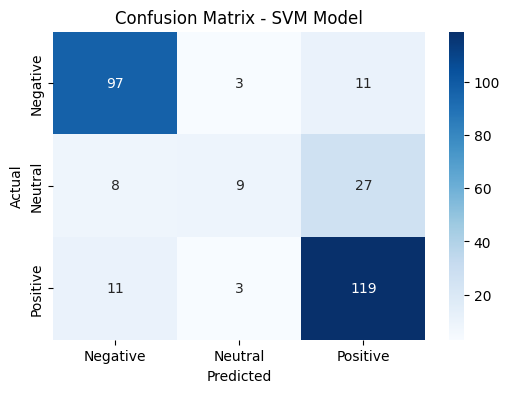

In [81]:
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM Model")

plt.show()